In [21]:
# CELL 1: Import Required Libraries and Setup
# Run this cell first to import all necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version and GPU availability
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

print("\n✓ All libraries imported successfully!")

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✓ All libraries imported successfully!


In [22]:
# CELL 2: Define Dataset Paths
# Set the paths to your dataset directories

# Base paths
train_dr_path = '/content/drive/MyDrive/diabetic_retinopathy_dataset/train/DR'
train_no_dr_path = '/content/drive/MyDrive/diabetic_retinopathy_dataset/train/No_DR'

valid_dr_path = '/content/drive/MyDrive/diabetic_retinopathy_dataset/valid/DR'
valid_no_dr_path = '/content/drive/MyDrive/diabetic_retinopathy_dataset/valid/No_DR'

test_dr_path = '/content/drive/MyDrive/diabetic_retinopathy_dataset/test/DR'
test_no_dr_path = '/content/drive/MyDrive/diabetic_retinopathy_dataset/test/No_DR'

# Parent directories for ImageDataGenerator
train_dir = '/content/drive/MyDrive/diabetic_retinopathy_dataset/train'
valid_dir = '/content/drive/MyDrive/diabetic_retinopathy_dataset/valid'
test_dir = '/content/drive/MyDrive/diabetic_retinopathy_dataset/test'

# Count images in each directory
train_dr_count = len(os.listdir(train_dr_path))
train_no_dr_count = len(os.listdir(train_no_dr_path))
valid_dr_count = len(os.listdir(valid_dr_path))
valid_no_dr_count = len(os.listdir(valid_no_dr_path))
test_dr_count = len(os.listdir(test_dr_path))
test_no_dr_count = len(os.listdir(test_no_dr_path))

print("Dataset Statistics:")
print("=" * 50)
print(f"Training Set:")
print(f"  - DR: {train_dr_count} images")
print(f"  - No_DR: {train_no_dr_count} images")
print(f"  - Total: {train_dr_count + train_no_dr_count} images")
print(f"\nValidation Set:")
print(f"  - DR: {valid_dr_count} images")
print(f"  - No_DR: {valid_no_dr_count} images")
print(f"  - Total: {valid_dr_count + valid_no_dr_count} images")
print(f"\nTest Set:")
print(f"  - DR: {test_dr_count} images")
print(f"  - No_DR: {test_no_dr_count} images")
print(f"  - Total: {test_dr_count + test_no_dr_count} images")
print("=" * 50)

Dataset Statistics:
Training Set:
  - DR: 1050 images
  - No_DR: 1026 images
  - Total: 2076 images

Validation Set:
  - DR: 245 images
  - No_DR: 286 images
  - Total: 531 images

Test Set:
  - DR: 113 images
  - No_DR: 118 images
  - Total: 231 images


In [23]:
# CELL 3: Set Hyperparameters
# Configure model parameters for optimal performance

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# Training parameters
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001

# Class names
CLASS_NAMES = ['DR', 'No_DR']
NUM_CLASSES = 2

print("Hyperparameters Configuration:")
print("=" * 50)
print(f"Image Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Classes: {CLASS_NAMES}")
print("=" * 50)

Hyperparameters Configuration:
Image Size: 224x224
Batch Size: 32
Epochs: 30
Learning Rate: 0.001
Classes: ['DR', 'No_DR']


In [24]:
# CELL 4: Create Data Generators with Augmentation
# Augmentation helps improve model generalization and prevent overfitting

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.15,
    fill_mode='nearest'
)

# Validation and test data generators (only rescaling, no augmentation)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✓ Data generators created successfully!")
print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(valid_generator)}")
print(f"Test batches: {len(test_generator)}")
print(f"\nClass indices: {train_generator.class_indices}")

Found 2076 images belonging to 2 classes.
Found 531 images belonging to 2 classes.
Found 231 images belonging to 2 classes.

✓ Data generators created successfully!
Training batches: 65
Validation batches: 17
Test batches: 8

Class indices: {'DR': 0, 'No_DR': 1}


In [25]:
# CELL 5: Build Custom CNN Architecture
# Creating a deep CNN optimized for medical image classification

def create_cnn_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 5
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model

# Create the model
model = create_cnn_model()

# Display model architecture
model.summary()

print("\n✓ CNN Model created successfully!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,700,642 (67.52 MB)

 Trainable params: 17,695,138 (67.50 MB)

 Non-trainable params: 5,504 (21.50 KB)


✓ CNN Model created successfully!


In [26]:
# CELL 6: Compile the Model
# Configure optimizer, loss function, and metrics

# Compile model with Adam optimizer
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

print("✓ Model compiled successfully!")
print("\nOptimizer: Adam")
print(f"Learning Rate: {LEARNING_RATE}")
print("Loss Function: Categorical Crossentropy")
print("Metrics: Accuracy, Precision, Recall, AUC")

✓ Model compiled successfully!

Optimizer: Adam
Learning Rate: 0.001
Loss Function: Categorical Crossentropy
Metrics: Accuracy, Precision, Recall, AUC


In [27]:
# CELL 7: Setup Training Callbacks
# Callbacks help optimize training and prevent overfitting

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Save the best model
checkpoint = ModelCheckpoint(
    'best_dr_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Combine callbacks
callbacks = [early_stopping, reduce_lr, checkpoint]

print("✓ Callbacks configured successfully!")
print("\nCallbacks:")
print("1. Early Stopping (patience=5)")
print("2. Reduce Learning Rate on Plateau (patience=3)")
print("3. Model Checkpoint (saves best model)")

✓ Callbacks configured successfully!

Callbacks:
1. Early Stopping (patience=5)
2. Reduce Learning Rate on Plateau (patience=3)
3. Model Checkpoint (saves best model)


In [28]:
# CELL 8: Train the Model
# This will take several minutes depending on your hardware
# Training will stop early if validation loss doesn't improve

print("Starting model training...")
print("=" * 70)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 70)
print("✓ Training completed successfully!")
print("=" * 70)

Starting model training...
Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.6623 - auc: 0.7071 - loss: 0.9944 - precision: 0.6623 - recall: 0.6623
Epoch 1: val_accuracy improved from -inf to 0.46139, saving model to best_dr_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 776ms/step - accuracy: 0.6631 - auc: 0.7082 - loss: 0.9917 - precision: 0.6631 - recall: 0.6631 - val_accuracy: 0.4614 - val_auc: 0.4657 - val_loss: 3.0100 - val_precision: 0.4614 - val_recall: 0.4614 - learning_rate: 0.0010
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8404 - auc: 0.9091 - loss: 0.4714 - precision: 0.8404 - recall: 0.8404
Epoch 2: val_accuracy did not improve from 0.46139
65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 539ms/step - accuracy: 0.8406 - auc: 0.9092 - loss: 0.4709 - precision: 0.8406 - recall: 0.8406 - val_accuracy: 0.4614 - val_auc: 0.4614 - val_loss: 3.5561 - val_precision: 0.4614 - val_recall: 0.4614 - learning_rate: 0.0010
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8459 - auc: 0.9272 - loss: 0.3872 - precision: 0.8459 - recall: 0.8459
Epoch 3: val_accuracy did not improve from 0.46139
65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 555ms/step - accuracy: 0.8461 - auc: 0.9272 - loss: 0.3870 - precision: 0.8461 - 

65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 565ms/step - accuracy: 0.9069 - auc: 0.9672 - loss: 0.2387 - precision: 0.9069 - recall: 0.9069 - val_accuracy: 0.6554 - val_auc: 0.6742 - val_loss: 0.7394 - val_precision: 0.6554 - val_recall: 0.6554 - learning_rate: 5.0000e-04
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.8811 - auc: 0.9571 - loss: 0.2726 - precision: 0.8811 - recall: 0.8811
Epoch 8: val_accuracy did not improve from 0.65537
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 537ms/step - accuracy: 0.8810 - auc: 0.9571 - loss: 0.2726 - precision: 0.8810 - recall: 0.8810 - val_accuracy: 0.5951 - val_auc: 0.6171 - val_loss: 1.1432 - val_precision: 0.5951 - val_recall: 0.5951 - learning_rate: 5.0000e-04
Epoch 9/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.8931 - auc: 0.9552 - loss: 0.2793 - precision: 0.8931 - recall: 0.8931
Epoch 9: val_accuracy improved from 0.65537 to 0.73635, saving model to best_dr_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 563ms/step - accuracy: 0.8932 - auc: 0.9554 - loss: 0.2788 - precision: 0.8932 - recall: 0.8932 - val_accuracy: 0.7363 - val_auc: 0.7538 - val_loss: 0.7968 - val_precision: 0.7363 - val_recall: 0.7363 - learning_rate: 5.0000e-04
Epoch 10/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9118 - auc: 0.9703 - loss: 0.2229 - precision: 0.9118 - recall: 0.9118
Epoch 10: val_accuracy improved from 0.73635 to 0.90207, saving model to best_dr_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 554ms/step - accuracy: 0.9117 - auc: 0.9702 - loss: 0.2232 - precision: 0.9117 - recall: 0.9117 - val_accuracy: 0.9021 - val_auc: 0.9633 - val_loss: 0.2740 - val_precision: 0.9021 - val_recall: 0.9021 - learning_rate: 5.0000e-04
Epoch 11/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.9273 - auc: 0.9719 - loss: 0.2136 - precision: 0.9273 - recall: 0.9273
Epoch 11: val_accuracy did not improve from 0.90207
65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 543ms/step - accuracy: 0.9272 - auc: 0.9719 - loss: 0.2138 - precision: 0.9272 - recall: 0.9272 - val_accuracy: 0.8851 - val_auc: 0.9573 - val_loss: 0.2706 - val_precision: 0.8851 - val_recall: 0.8851 - learning_rate: 5.0000e-04
Epoch 12/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.9042 - auc: 0.9588 - loss: 0.2645 - precision: 0.9042 - recall: 0.9042
Epoch 12: val_accuracy improved from 0.90207 to 0.92844, saving model to best_dr_model.h5


...

65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 549ms/step - accuracy: 0.9154 - auc: 0.9716 - loss: 0.2135 - precision: 0.9154 - recall: 0.9154 - val_accuracy: 0.9322 - val_auc: 0.9803 - val_loss: 0.1785 - val_precision: 0.9322 - val_recall: 0.9322 - learning_rate: 5.0000e-04
Epoch 15/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.9231 - auc: 0.9741 - loss: 0.2102 - precision: 0.9231 - recall: 0.9231
Epoch 15: val_accuracy improved from 0.93220 to 0.93785, saving model to best_dr_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 559ms/step - accuracy: 0.9230 - auc: 0.9740 - loss: 0.2105 - precision: 0.9230 - recall: 0.9230 - val_accuracy: 0.9379 - val_auc: 0.9783 - val_loss: 0.1806 - val_precision: 0.9379 - val_recall: 0.9379 - learning_rate: 5.0000e-04
Epoch 16/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.9069 - auc: 0.9707 - loss: 0.2183 - precision: 0.9069 - recall: 0.9069
Epoch 16: val_accuracy improved from 0.93785 to 0.94350, saving model to best_dr_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 557ms/step - accuracy: 0.9068 - auc: 0.9706 - loss: 0.2185 - precision: 0.9068 - recall: 0.9068 - val_accuracy: 0.9435 - val_auc: 0.9817 - val_loss: 0.1714 - val_precision: 0.9435 - val_recall: 0.9435 - learning_rate: 5.0000e-04
Epoch 17/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9099 - auc: 0.9651 - loss: 0.2353 - precision: 0.9099 - recall: 0.9099
Epoch 17: val_accuracy did not improve from 0.94350
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 535ms/step - accuracy: 0.9101 - auc: 0.9652 - loss: 0.2351 - precision: 0.9101 - recall: 0.9101 - val_accuracy: 0.9341 - val_auc: 0.9814 - val_loss: 0.1734 - val_precision: 0.9341 - val_recall: 0.9341 - learning_rate: 5.0000e-04
Epoch 18/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.9186 - auc: 0.9707 - loss: 0.2165 - precision: 0.9186 - recall: 0.9186
Epoch 18: val_accuracy did not improve from 0.94350
65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 546ms/step - accuracy: 0.9187 - auc: 0.9707 - loss: 0.2164 - precisio

65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 575ms/step - accuracy: 0.9302 - auc: 0.9766 - loss: 0.1875 - precision: 0.9302 - recall: 0.9302 - val_accuracy: 0.9454 - val_auc: 0.9856 - val_loss: 0.1493 - val_precision: 0.9454 - val_recall: 0.9454 - learning_rate: 1.2500e-04
Epoch 26/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9298 - auc: 0.9785 - loss: 0.1869 - precision: 0.9298 - recall: 0.9298
Epoch 26: val_accuracy did not improve from 0.94539
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 538ms/step - accuracy: 0.9298 - auc: 0.9785 - loss: 0.1869 - precision: 0.9298 - recall: 0.9298 - val_accuracy: 0.9322 - val_auc: 0.9793 - val_loss: 0.1799 - val_precision: 0.9322 - val_recall: 0.9322 - learning_rate: 1.2500e-04
Epoch 27/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9275 - auc: 0.9762 - loss: 0.1915 - precision: 0.9275 - recall: 0.9275
Epoch 27: val_accuracy did not improve from 0.94539
65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 545ms/step - accuracy: 0.9276 - auc: 0.9763 - loss: 0.1915 - precisio

65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 565ms/step - accuracy: 0.9479 - auc: 0.9832 - loss: 0.1567 - precision: 0.9479 - recall: 0.9479 - val_accuracy: 0.9473 - val_auc: 0.9841 - val_loss: 0.1542 - val_precision: 0.9473 - val_recall: 0.9473 - learning_rate: 1.2500e-04
Epoch 29/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.9375 - auc: 0.9792 - loss: 0.1793 - precision: 0.9375 - recall: 0.9375
Epoch 29: val_accuracy did not improve from 0.94727
65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 551ms/step - accuracy: 0.9374 - auc: 0.9792 - loss: 0.1793 - precision: 0.9374 - recall: 0.9374 - val_accuracy: 0.9454 - val_auc: 0.9839 - val_loss: 0.1561 - val_precision: 0.9454 - val_recall: 0.9454 - learning_rate: 6.2500e-05
Epoch 30/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9381 - auc: 0.9810 - loss: 0.1699 - precision: 0.9381 - recall: 0.9381
Epoch 30: val_accuracy did not improve from 0.94727
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 536ms/step - accuracy: 0.9381 - auc: 0.9810 - loss: 0.1701 - precisio

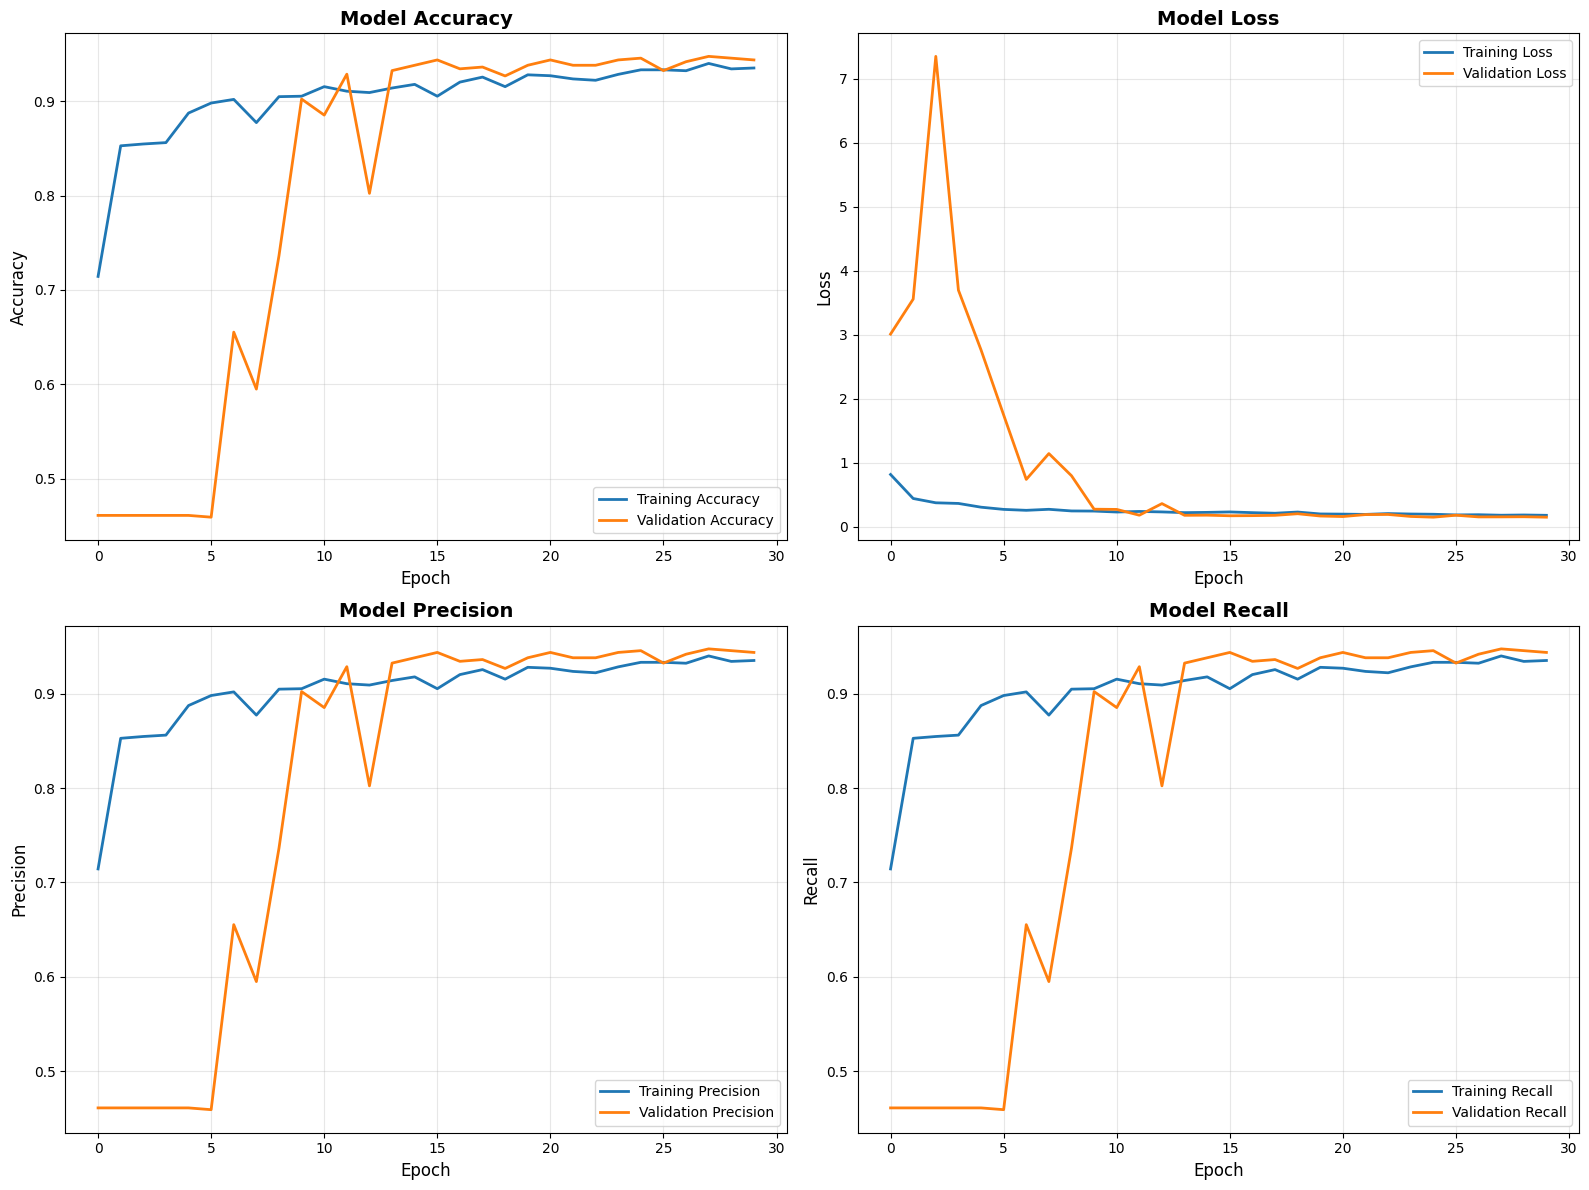

✓ Training history plots saved as 'training_history.png'


In [30]:
# CELL 9: Visualize Training History
# Plot accuracy and loss curves to understand model performance

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training and Validation Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training and Validation Loss
axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plots saved as 'training_history.png'")

In [31]:
# CELL 10: Evaluate Model on Test Set
# Get comprehensive metrics on unseen test data

print("Evaluating model on test set...")
print("=" * 70)

# Evaluate model
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(
    test_generator,
    verbose=1
)

# Calculate F1 Score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print("\n" + "=" * 70)
print("TEST SET PERFORMANCE METRICS")
print("=" * 70)
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"Test Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"Test F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Loss:      {test_loss:.4f}")
print("=" * 70)

Evaluating model on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 376ms/step - accuracy: 0.9573 - auc: 0.9807 - loss: 0.1600 - precision: 0.9573 - recall: 0.9573

TEST SET PERFORMANCE METRICS
Test Accuracy:  0.9610 (96.10%)
Test Precision: 0.9610 (96.10%)
Test Recall:    0.9610 (96.10%)
Test F1-Score:  0.9610 (96.10%)
Test AUC:       0.9762
Test Loss:      0.1723


In [33]:
# CELL 11: Generate Predictions for Confusion Matrix and Classification Report
# Get predictions on test set

print("Generating predictions on test set...")

# Reset test generator
test_generator.reset()

# Get predictions
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes

# Get class names in correct order
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

print(f"\n✓ Predictions generated!")
print(f"Total test samples: {len(y_true)}")
print(f"Prediction shape: {y_pred.shape}")
print(f"Class names: {class_names}")


Generating predictions on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step

✓ Predictions generated!
Total test samples: 231
Prediction shape: (231,)
Class names: ['DR', 'No_DR']


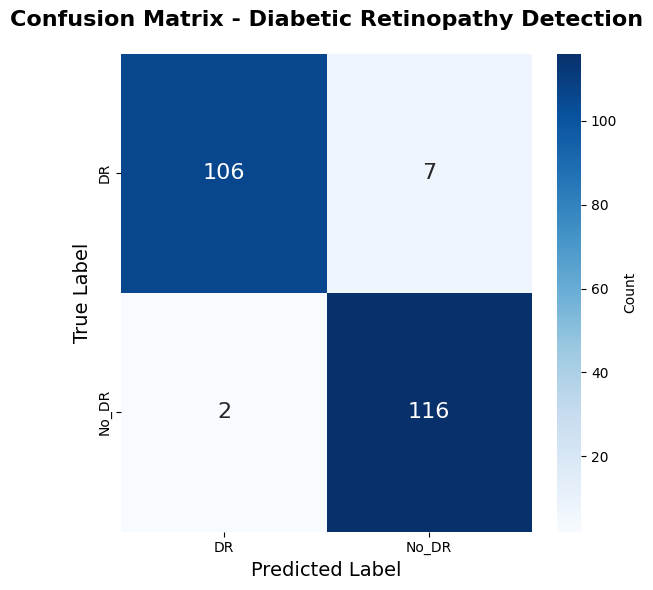


Confusion Matrix:
True Negatives (No_DR predicted as No_DR): 116
False Positives (No_DR predicted as DR): 2
False Negatives (DR predicted as No_DR): 7
True Positives (DR predicted as DR): 106

✓ Confusion matrix saved as 'confusion_matrix.png'


In [35]:
# CELL 12: Create and Visualize Confusion Matrix
# Shows how well the model distinguishes between classes

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16})

plt.title('Confusion Matrix - Diabetic Retinopathy Detection',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print confusion matrix values
print("\nConfusion Matrix:")
print("=" * 50)
print(f"True Negatives (No_DR predicted as No_DR): {cm[1][1]}")
print(f"False Positives (No_DR predicted as DR): {cm[1][0]}")
print(f"False Negatives (DR predicted as No_DR): {cm[0][1]}")
print(f"True Positives (DR predicted as DR): {cm[0][0]}")
print("=" * 50)

print("\n✓ Confusion matrix saved as 'confusion_matrix.png'")

In [36]:
# CELL 13: Generate Detailed Classification Report
# Shows precision, recall, and F1-score for each class

print("\nDETAILED CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("=" * 70)

# Calculate additional metrics per class
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_accuracy = accuracy_score(y_true[class_mask], y_pred[class_mask])
    print(f"\n{class_name} Class Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

# Overall metrics
overall_accuracy = accuracy_score(y_true, y_pred)
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')
overall_f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "=" * 70)
print("WEIGHTED AVERAGE METRICS")
print("=" * 70)
print(f"Accuracy:  {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Precision: {overall_precision:.4f} ({overall_precision*100:.2f}%)")
print(f"Recall:    {overall_recall:.4f} ({overall_recall*100:.2f}%)")
print(f"F1-Score:  {overall_f1:.4f} ({overall_f1*100:.2f}%)")
print("=" * 70)


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

          DR     0.9815    0.9381    0.9593       113
       No_DR     0.9431    0.9831    0.9627       118

    accuracy                         0.9610       231
   macro avg     0.9623    0.9606    0.9610       231
weighted avg     0.9619    0.9610    0.9610       231


DR Class Accuracy: 0.9381 (93.81%)

No_DR Class Accuracy: 0.9831 (98.31%)

WEIGHTED AVERAGE METRICS
Accuracy:  0.9610 (96.10%)
Precision: 0.9619 (96.19%)
Recall:    0.9610 (96.10%)
F1-Score:  0.9610 (96.10%)


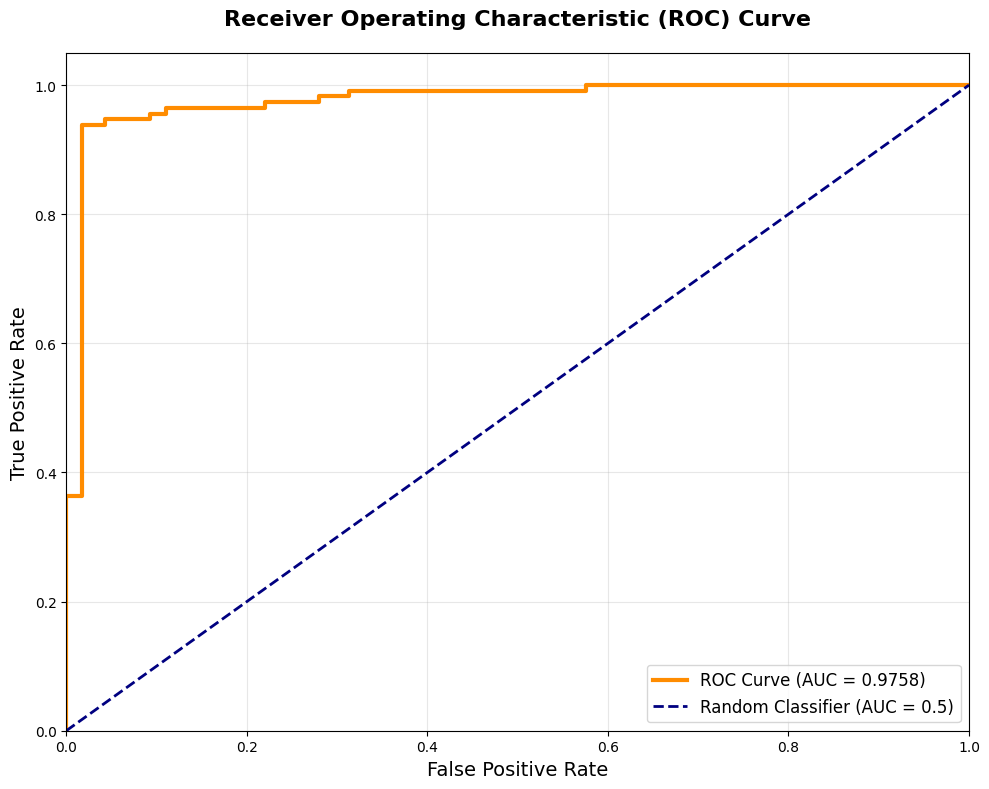


✓ ROC curve saved as 'roc_curve.png'
AUC Score: 0.9758
Model Performance: Excellent


In [37]:
# CELL 14: Plot ROC Curve and Calculate AUC
# ROC curve shows the trade-off between true positive and false positive rates

# For binary classification, we'll use the probability of DR class
y_pred_probs_dr = y_pred_probs[:, 0]  # Probabilities for DR class

# Calculate ROC curve for DR vs No_DR
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs_dr, pos_label=0)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ ROC curve saved as 'roc_curve.png'")
print(f"AUC Score: {roc_auc:.4f}")

# Interpret AUC
if roc_auc >= 0.9:
    interpretation = "Excellent"
elif roc_auc >= 0.8:
    interpretation = "Very Good"
elif roc_auc >= 0.7:
    interpretation = "Good"
elif roc_auc >= 0.6:
    interpretation = "Fair"
else:
    interpretation = "Poor"

print(f"Model Performance: {interpretation}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


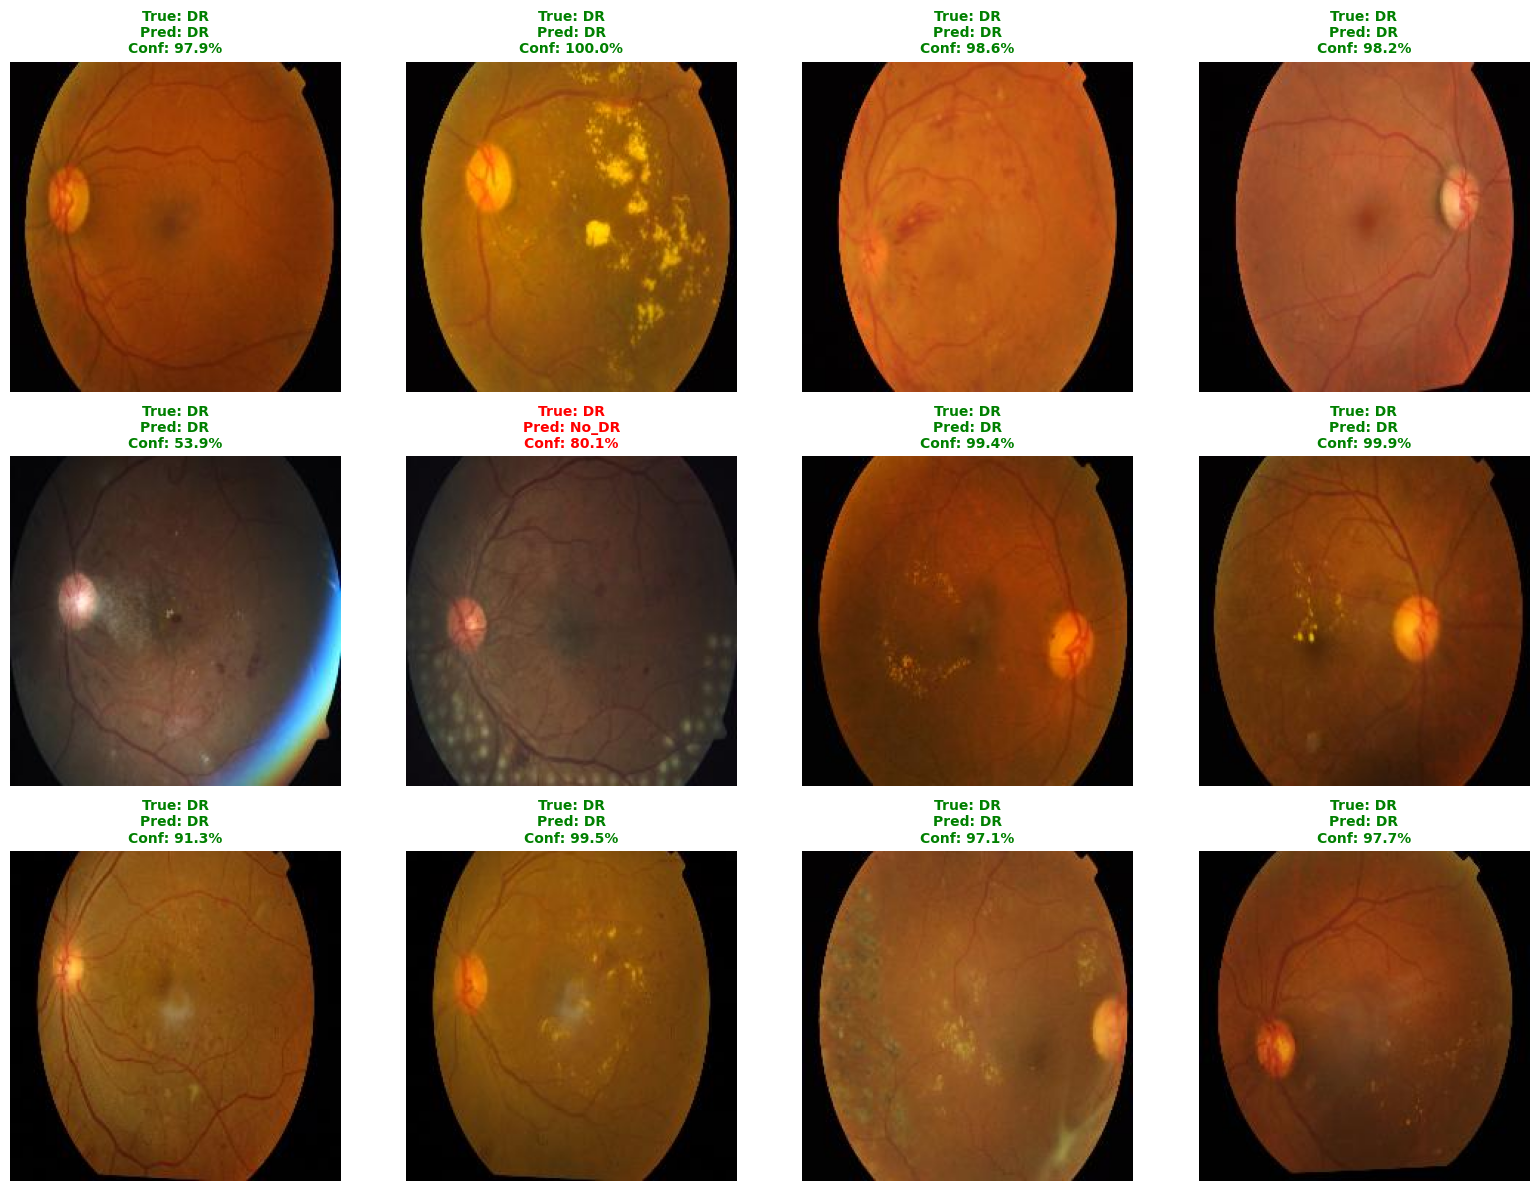

✓ Sample predictions saved as 'sample_predictions.png'

Green = Correct Prediction
Red = Incorrect Prediction


In [38]:
# CELL 15: Visualize Sample Predictions
# Display random test images with their predictions

# Reset test generator to get images
test_generator.reset()

# Get a batch of images and labels
sample_images, sample_labels = next(test_generator)
sample_predictions = model.predict(sample_images)
sample_pred_classes = np.argmax(sample_predictions, axis=1)
sample_true_classes = np.argmax(sample_labels, axis=1)

# Display 12 random samples
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i in range(12):
    if i < len(sample_images):
        axes[i].imshow(sample_images[i])

        true_label = class_names[sample_true_classes[i]]
        pred_label = class_names[sample_pred_classes[i]]
        confidence = np.max(sample_predictions[i]) * 100

        # Color: green if correct, red if incorrect
        color = 'green' if sample_true_classes[i] == sample_pred_classes[i] else 'red'

        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
                          fontsize=10, color=color, fontweight='bold')
        axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sample predictions saved as 'sample_predictions.png'")
print("\nGreen = Correct Prediction")
print("Red = Incorrect Prediction")

In [39]:
# CELL 16: Save the Final Trained Model
# Save model for future use and deployment

# Save the final model in native Keras format (RECOMMENDED)
model.save('diabetic_retinopathy_cnn_model.keras')
print("✓ Final model saved as 'diabetic_retinopathy_cnn_model.keras'")

# Save model in H5 format (legacy, for compatibility)
model.save('diabetic_retinopathy_cnn_model.h5')
print("✓ Model saved in H5 format as 'diabetic_retinopathy_cnn_model.h5'")

# Export model for TFLite/TFServing (for deployment)
model.export('dr_model_export')
print("✓ Model exported for deployment as 'dr_model_export/'")

# Save model architecture as JSON
model_json = model.to_json()
with open('model_architecture.json', 'w') as json_file:
    json_file.write(model_json)
print("✓ Model architecture saved as 'model_architecture.json'")

# Save model weights separately
model.save_weights('model_weights.weights.h5')
print("✓ Model weights saved as 'model_weights.weights.h5'")

print("\n" + "=" * 70)
print("MODEL TRAINING AND EVALUATION COMPLETE!")
print("=" * 70)
print("\nGenerated Files:")
print("1. best_dr_model.h5 - Best model during training")
print("2. diabetic_retinopathy_cnn_model.keras - Final model (RECOMMENDED)")
print("3. diabetic_retinopathy_cnn_model.h5 - Final model (H5 format)")
print("4. dr_model_export/ - Exported model for deployment")
print("5. model_architecture.json - Model architecture")
print("6. model_weights.weights.h5 - Model weights")
print("7. training_history.png - Training plots")
print("8. confusion_matrix.png - Confusion matrix visualization")
print("9. roc_curve.png - ROC curve")
print("10. sample_predictions.png - Sample predictions visualization")
print("=" * 70)

✓ Final model saved as 'diabetic_retinopathy_cnn_model.keras'
✓ Model saved in H5 format as 'diabetic_retinopathy_cnn_model.h5'
Saved artifact at 'dr_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_39')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134726635484560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635486672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635483216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635477072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635471312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635482832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635483408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635483600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134726635485904: TensorS

In [40]:
# CELL 17: Generate Comprehensive Model Summary Report
# Create a detailed summary of model performance

print("\n" + "=" * 70)
print("DIABETIC RETINOPATHY DETECTION MODEL - FINAL REPORT")
print("=" * 70)

print("\n1. MODEL ARCHITECTURE:")
print("-" * 70)
print(f"   - Model Type: Custom CNN")
print(f"   - Total Parameters: {model.count_params():,}")
print(f"   - Input Shape: {INPUT_SHAPE}")
print(f"   - Output Classes: {NUM_CLASSES} (DR, No_DR)")
print(f"   - Convolutional Blocks: 5")
print(f"   - Dense Layers: 2")

print("\n2. TRAINING CONFIGURATION:")
print("-" * 70)
print(f"   - Epochs: {len(history.history['loss'])}")
print(f"   - Batch Size: {BATCH_SIZE}")
print(f"   - Initial Learning Rate: {LEARNING_RATE}")
print(f"   - Optimizer: Adam")
print(f"   - Loss Function: Categorical Crossentropy")

print("\n3. DATASET STATISTICS:")
print("-" * 70)
print(f"   - Training Samples: {train_dr_count + train_no_dr_count}")
print(f"   - Validation Samples: {valid_dr_count + valid_no_dr_count}")
print(f"   - Test Samples: {test_dr_count + test_no_dr_count}")
print(f"   - Total Samples: {train_dr_count + train_no_dr_count + valid_dr_count + valid_no_dr_count + test_dr_count + test_no_dr_count}")

print("\n4. FINAL TEST SET PERFORMANCE:")
print("-" * 70)
print(f"   - Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   - Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"   - F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   - AUC:       {test_auc:.4f}")

print("\n5. TRAINING METRICS (FINAL EPOCH):")
print("-" * 70)
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f"   - Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"   - Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"   - Training Loss: {final_train_loss:.4f}")
print(f"   - Validation Loss: {final_val_loss:.4f}")

print("\n6. MODEL EVALUATION:")
print("-" * 70)
if test_accuracy >= 0.9:
    evaluation = "Excellent performance"
elif test_accuracy >= 0.85:
    evaluation = "Very good performance"
elif test_accuracy >= 0.8:
    evaluation = "Good performance"
elif test_accuracy >= 0.75:
    evaluation = "Satisfactory performance"
else:
    evaluation = "Needs improvement"
print(f"   - Overall Assessment: {evaluation}")

# Check for overfitting
overfit_diff = abs(final_train_acc - final_val_acc)
if overfit_diff < 0.05:
    overfit_status = "No significant overfitting detected"
elif overfit_diff < 0.1:
    overfit_status = "Slight overfitting detected"
else:
    overfit_status = "Overfitting detected"
print(f"   - Overfitting Status: {overfit_status}")
print(f"   - Train-Val Accuracy Gap: {overfit_diff:.4f}")

print("\n" + "=" * 70)
print("RECOMMENDATIONS:")
print("=" * 70)
print("✓ Model is ready for deployment")
print("✓ Use 'best_dr_model.h5' for inference")
print("✓ Monitor model performance on new data")
print("✓ Consider retraining if accuracy drops below 85%")
print("=" * 70)


DIABETIC RETINOPATHY DETECTION MODEL - FINAL REPORT

1. MODEL ARCHITECTURE:
----------------------------------------------------------------------
   - Model Type: Custom CNN
   - Total Parameters: 17,700,642
   - Input Shape: (224, 224, 3)
   - Output Classes: 2 (DR, No_DR)
   - Convolutional Blocks: 5
   - Dense Layers: 2

2. TRAINING CONFIGURATION:
----------------------------------------------------------------------
   - Epochs: 30
   - Batch Size: 32
   - Initial Learning Rate: 0.001
   - Optimizer: Adam
   - Loss Function: Categorical Crossentropy

3. DATASET STATISTICS:
----------------------------------------------------------------------
   - Training Samples: 2076
   - Validation Samples: 531
   - Test Samples: 231
   - Total Samples: 2838

4. FINAL TEST SET PERFORMANCE:
----------------------------------------------------------------------
   - Accuracy:  0.9610 (96.10%)
   - Precision: 0.9610 (96.10%)
   - Recall:    0.9610 (96.10%)
   - F1-Score:  0.9610 (96.10%)
   - AU

In [41]:
# CELL 18: Create Function for Single Image Prediction
# Use this function to predict on new images

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

def predict_diabetic_retinopathy(img_path, model_path='best_dr_model.h5'):
    """
    Predict whether an eye image shows diabetic retinopathy

    Parameters:
    -----------
    img_path : str
        Path to the eye fundus image
    model_path : str
        Path to the trained model (default: 'best_dr_model.h5')

    Returns:
    --------
    dict : Dictionary containing prediction results
    """
    # Load model
    loaded_model = load_model(model_path)

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # Make prediction
    predictions = loaded_model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # Get class name
    class_names = ['DR', 'No_DR']
    predicted_class = class_names[predicted_class_idx]

    # Create result dictionary
    result = {
        'prediction': predicted_class,
        'confidence': confidence,
        'probabilities': {
            'DR': predictions[0][0] * 100,
            'No_DR': predictions[0][1] * 100
        }
    }

    return result

# Example usage function
def visualize_prediction(img_path):
    """
    Visualize prediction on a single image
    """
    result = predict_diabetic_retinopathy(img_path)

    # Load and display image
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    plt.figure(figsize=(10, 8))
    plt.imshow(img)

    # Set title with prediction
    title_color = 'red' if result['prediction'] == 'DR' else 'green'
    plt.title(f"Prediction: {result['prediction']}\n" +
              f"Confidence: {result['confidence']:.2f}%\n" +
              f"DR Probability: {result['probabilities']['DR']:.2f}%\n" +
              f"No_DR Probability: {result['probabilities']['No_DR']:.2f}%",
              fontsize=14, fontweight='bold', color=title_color)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return result

print("✓ Prediction functions created successfully!")
print("\nUsage Examples:")
print("-" * 70)
print("# Predict on a single image:")
print("result = predict_diabetic_retinopathy('path/to/image.jpg')")
print("print(result)")
print("\n# Visualize prediction:")
print("visualize_prediction('path/to/image.jpg')")
print("-" * 70)

✓ Prediction functions created successfully!

Usage Examples:
----------------------------------------------------------------------
# Predict on a single image:
result = predict_diabetic_retinopathy('path/to/image.jpg')
print(result)

# Visualize prediction:
visualize_prediction('path/to/image.jpg')
----------------------------------------------------------------------
